# FraudGNN

```
[1] preprocesar   CSV → tabla limpia + features derivadas       (en memoria)
[2] grafo         transacción ↔ {uid, card, email, device, net} + normalización
[3] GNN           entrenar LA red ganadora (búsqueda y 6 redes: apagadas)
[4] embedding     la red congelada describe lo que no entrenó
[5] cabezas       control / solo_gnn / gnn_mas_tabular (XGBoost)
[6] veredicto     examen + bootstrap + gráficos comparativos
```


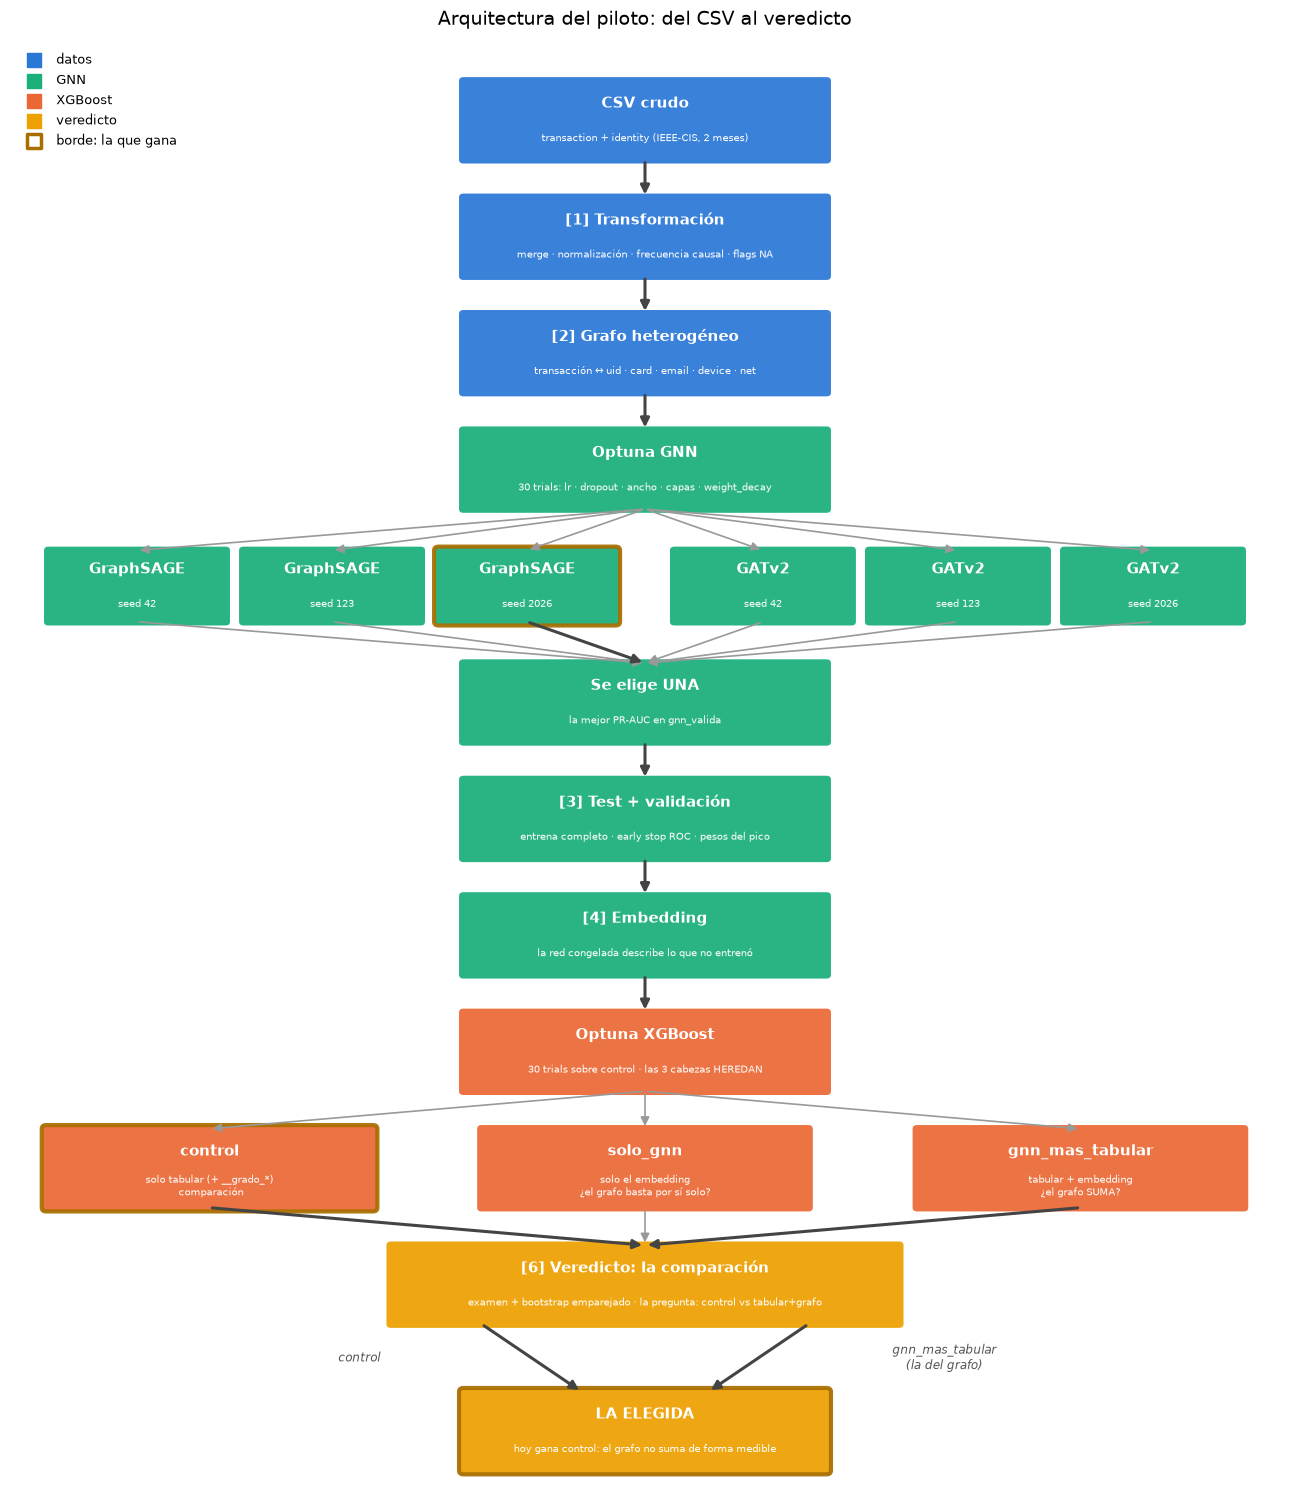

In [1]:
# ── Diagrama de la arquitectura: del CSV al veredicto, con las bifurcaciones
# Autocontenido a propósito: corre antes de la celda de entorno.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

C_DATO, C_GNN, C_XGB, C_FIN = "#2a78d6", "#1baf7a", "#eb6834", "#eda100"

fig, ax = plt.subplots(figsize=(13, 15))
ax.set_xlim(0, 14); ax.set_ylim(-0.55, 18.6); ax.axis("off")
CX = 7.0                                   # el eje central del flujo

def caja(cx, cy, w, h, titulo, detalle, color, ganadora=False):
    ax.add_patch(FancyBboxPatch((cx - w/2, cy - h/2), w, h,
                                boxstyle="round,pad=0.05", facecolor=color,
                                edgecolor="#a86e00" if ganadora else "none",
                                linewidth=3 if ganadora else 0, alpha=0.93))
    dy = 0.22 if detalle else 0
    ax.text(cx, cy + dy, titulo, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color="white")
    if detalle:
        ax.text(cx, cy - 0.24, detalle, ha="center", va="center",
                fontsize=7.5, color="white")
    return cx, cy

def flecha(p, q, gruesa=False):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle="-|>", mutation_scale=13,
                                 color="#444444" if gruesa else "#999999",
                                 linewidth=2.2 if gruesa else 1.2,
                                 shrinkA=2, shrinkB=2))

W, H = 4.0, 1.05                           # cajas del eje central
Y = dict(csv=17.55, transf=16.0, grafo=14.45, opt_gnn=12.9, redes=11.35,
         elige=9.8, test=8.25, emb=6.7, opt_xgb=5.15, cabezas=3.6,
         veredicto=2.05, elegida=0.1)

# ── el eje central ───────────────────────────────────────────────────────────
caja(CX, Y["csv"],    W, H, "CSV crudo", "transaction + identity (IEEE-CIS, 2 meses)", C_DATO)
caja(CX, Y["transf"], W, H, "[1] Transformación", "merge · normalización · frecuencia causal · flags NA", C_DATO)
caja(CX, Y["grafo"],  W, H, "[2] Grafo heterogéneo", "transacción ↔ uid · card · email · device · net", C_DATO)
caja(CX, Y["opt_gnn"], W, H, "Optuna GNN", "30 trials: lr · dropout · ancho · capas · weight_decay", C_GNN)
caja(CX, Y["elige"],  W, H, "Se elige UNA", "la mejor PR-AUC en gnn_valida", C_GNN)
caja(CX, Y["test"],   W, H, "[3] Test + validación", "entrena completo · early stop ROC · pesos del pico", C_GNN)
caja(CX, Y["emb"],    W, H, "[4] Embedding", "la red congelada describe lo que no entrenó", C_GNN)
caja(CX, Y["opt_xgb"], W, H, "Optuna XGBoost", "30 trials sobre control · las 3 cabezas HEREDAN", C_XGB)
caja(CX, Y["veredicto"], W + 1.6, H, "[6] Veredicto: la comparación",
     "examen + bootstrap emparejado · la pregunta: control vs tabular+grafo", C_FIN)
caja(CX, Y["elegida"], W, H, "LA ELEGIDA", "hoy gana control: el grafo no suma de forma medible", C_FIN, ganadora=True)

for a, b in [("csv", "transf"), ("transf", "grafo"), ("grafo", "opt_gnn"),
             ("elige", "test"), ("test", "emb"), ("emb", "opt_xgb")]:
    flecha((CX, Y[a] - H/2), (CX, Y[b] + H/2), gruesa=True)

# ── bifurcación 1: las 6 redes (2 arquitecturas × 3 semillas) ────────────────
w6, h6 = 1.95, 0.95
xs6 = [1.4, 3.55, 5.7, 8.3, 10.45, 12.6]
redes = [("GraphSAGE", 42), ("GraphSAGE", 123), ("GraphSAGE", 2026),
         ("GATv2", 42), ("GATv2", 123), ("GATv2", 2026)]
for x, (arq, seed) in zip(xs6, redes):
    gana = (arq == "GraphSAGE" and seed == 2026)     # la que ganó de verdad
    caja(x, Y["redes"], w6, h6, arq, f"seed {seed}", C_GNN, ganadora=gana)
    flecha((CX, Y["opt_gnn"] - H/2), (x, Y["redes"] + h6/2))
    flecha((x, Y["redes"] - h6/2), (CX, Y["elige"] + H/2), gruesa=gana)

# ── bifurcación 2: las 3 cabezas XGBoost ─────────────────────────────────────
w3, h3 = 3.6, 1.05
xs3 = {"control": 2.2, "solo_gnn": 7.0, "gnn_mas_tabular": 11.8}
caja(xs3["control"], Y["cabezas"], w3, h3, "control",
     "solo tabular (+ __grado_*)\n comparación", C_XGB, ganadora=True)
caja(xs3["solo_gnn"], Y["cabezas"], w3, h3, "solo_gnn",
     "solo el embedding\n¿el grafo basta por sí solo?", C_XGB)
caja(xs3["gnn_mas_tabular"], Y["cabezas"], w3, h3, "gnn_mas_tabular",
     "tabular + embedding\n¿el grafo SUMA?", C_XGB)
for nombre, x in xs3.items():
    clave = nombre in ("control", "gnn_mas_tabular")   # el duelo del capstone
    flecha((CX, Y["opt_xgb"] - H/2), (x, Y["cabezas"] + h3/2))
    flecha((x, Y["cabezas"] - h3/2), (CX, Y["veredicto"] + H/2), gruesa=clave)

# del veredicto salen las DOS finalistas y de ahí emerge la elegida
flecha((CX - 1.8, Y["veredicto"] - H/2), (CX - 0.7, Y["elegida"] + H/2), gruesa=True)
flecha((CX + 1.8, Y["veredicto"] - H/2), (CX + 0.7, Y["elegida"] + H/2), gruesa=True)
y_medio = (Y["veredicto"] - H/2 + Y["elegida"] + H/2) / 2
ax.text(CX - 3.15, y_medio, "control", ha="center", va="center",
        fontsize=8.5, color="#555555", style="italic")
ax.text(CX + 3.3, y_medio, "gnn_mas_tabular\n(la del grafo)", ha="center",
        va="center", fontsize=8.5, color="#555555", style="italic")

for texto, color in [("datos", C_DATO), ("GNN", C_GNN), ("XGBoost", C_XGB),
                     ("veredicto", C_FIN)]:
    ax.scatter([], [], s=90, marker="s", color=color, label=texto)
ax.scatter([], [], s=90, marker="s", facecolor="white", edgecolor="#a86e00",
           linewidth=2.5, label="borde: la que gana")
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.set_title("Arquitectura del piloto: del CSV al veredicto", fontsize=14, pad=12)
plt.tight_layout(); plt.show()

In [2]:
# dependencias de interfaz (barras de progreso)
%pip install -q ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [3]:
# ── Entorno ──────────────────────────────────────────────────────────────────
import os, sys, time, copy, random

# macOS: torch y xgboost traen cada uno su OpenMP; juntos multihilo segfaultean.
if sys.platform == "darwin":
    os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"dispositivo: {DEVICE} | torch {torch.__version__}")

def set_seed(seed=42):
    # modos deterministas incluidos: sin ellos, dos corridas con la MISMA
    # semilla difieren en GPU (el orden de las sumas paralelas cambia)
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    torch.use_deterministic_algorithms(True, warn_only=True)
    torch.backends.cudnn.deterministic, torch.backends.cudnn.benchmark = True, False

# paleta fija: el color sigue al SISTEMA en todos los gráficos
COLOR  = {"control": "#2a78d6", "gnn_mas_tabular": "#eb6834",
          "solo_gnn": "#1baf7a", "gnn_sola": "#eda100"}
NOMBRE = {"control": "Control (tabular)", "gnn_mas_tabular": "Tabular + grafo",
          "solo_gnn": "Solo embedding", "gnn_sola": "GNN directa"}
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 11})
pd.set_option("display.max_columns", None)


dispositivo: cpu | torch 2.13.0


## Configuración
La red tiene una entrada de 93 features normalizadas, 3 capas de 256 neuronas, despues se reduce a 16.

In [4]:
CFG = {
    "seconds_per_month": 2_592_000,    #Segundos de un mes
    # Ventana de datos
    "ventanas": {
        "gnn_entrena":      [(1, [1, 2])],            # (mes, semanas)
        "gnn_valida":       [(1, [3])],
        "cabezas_entrenan": [(1, [4]), (2, [1, 2])],
        "cabezas_validan":  [(2, [3])],
        "examen":           [(2, [4])],
    },

    "entidades": {
        "uid":    {"cols": ["card1", "addr1"], "usa_d1": True}, #usa_d1 dia del primero uso
        "card":   {"cols": ["card1", "card2", "card3", "card5"]},
        "email":  {"cols": ["P_emaildomain", "card1"]},
        "device": {"cols": ["DeviceInfo", "id_30", "id_31", "id_33"]},
        "net":    {"cols": ["id_13", "id_17", "id_19", "id_20"]},
    },
    "min_previas_entidad": 1,     # Si no tiene vecino el vector de los mismos es cero
    "vecinos_por_entidad": 10,    # Buscar las 10 mas recinetes
    # ── ablación y flags ─────────────────────────────────────────────────────
    "ablacion": ["V", "C", "D"],  # Sacar estos datos ya que estan ofuscados
    "umbral_flag_na": 0.20,       # % de vacios en train para crear el flag que indica que estaba nula
    # ── entrenamiento ────────────────────────────────────────────────────────
    "batch_size": 2048, "num_workers": 4, "prefetch_factor": 4, #Configuraciones para la ejecución
    "epochs": 50, "patience": 10, #Epocas y paciencia de la GNN
    # ── cabezas ──────────────────────────────────────────────────────────────
    "smote": {"sampling_strategy": 0.5, "k_neighbors": 5}, #1 fraude por cada 2 legitimas, se crea por 1 fraude y sus 5 fraudes muy parecidos
    "early_stopping_xgb": 50, #detener despues de tener 50 arboles sin mejoras
}

# Arquitectura de la GNN
ARQUITECTURA = "graphsage"     # "graphsage" | "gatv2"
SEED         = 2026            # 42 | 123 | 2026

# Hiperparametros RED mlp_head_dim -> Salida de la gnn | weight_decay -> restar al peso una fraccion de el para evitar sobre ajuste
USAR_OPTUNA = True
MEJORES_OPTUNA = {"lr": 3.620595965204201e-04, "dropout": 0.3376681522595246,
                  "ancho": 256, "capas": 3,
                  "weight_decay": 8.376070586201612e-06, "mlp_head_dim": 64}
MANUALES = {"lr": 1e-3, "dropout": 0.2, "ancho": 64, "capas": 2,
            "weight_decay": 5e-4, "mlp_head_dim": 32}
HP = dict(MEJORES_OPTUNA if USAR_OPTUNA else MANUALES)

FORZAR_MLP_HEAD_DIM = 16
if FORZAR_MLP_HEAD_DIM:
    HP["mlp_head_dim"] = FORZAR_MLP_HEAD_DIM

print(f"red: {ARQUITECTURA} seed {SEED} | {HP['ancho']}x{HP['capas']} capas | "
      f"embedding {HP['mlp_head_dim']}d | lr {HP['lr']:.2e}")

red: graphsage seed 2026 | 256x3 capas | embedding 16d | lr 3.62e-04


## [1] Preprocesamiento

Merge de transaction + identity y recorte a los 2 meses del piloto.

Normaliza numeros con log con signo mas z-score (Restar la media y despues dividir por la desviacion estandar)

Los texto lo pasamos a una frecuencua un numero asignado por texto ejemplo gmail=17, despues por cada gmail sumamos uno y tenemos la frecuencia de ese dato, si vamos en el gmail 5 y hemos visto 10 datos se divide 5/10, despues se pasa por z-score para normalizar

En el entrenamiento se rellenan los nulos numericos con la mediana por lo valores altos y categoricos con _NA_, en la validación con la mediana del entrenamiento, si una columna tiene mas del 20% nulo se agrega una nueva columa col_na=1 cuando este nulo y 0 cuando no este.


In [5]:
from pathlib import Path

def mascara(bloque, meses, semanas):
    """Máscara booleana de las filas del bloque (mes, semanas)."""
    out = np.zeros(len(meses), dtype=bool)
    for mes, sems in CFG["ventanas"][bloque]:
        out |= (np.asarray(meses) == mes) & np.isin(semanas, sems)
    return out

def ventanas_de(meses, semanas):
    """Las 5 máscaras, verificando que NINGUNA se solape con otra."""
    ms = {n: mascara(n, meses, semanas) for n in CFG["ventanas"]}
    nombres = list(ms)
    for i, a in enumerate(nombres):
        for b in nombres[i + 1:]:
            assert not (ms[a] & ms[b]).any(), f"¡{a} y {b} comparten filas!"
    return ms

def delta_tarjeta(df):
    """log1p(segundos desde la compra ANTERIOR de la misma card1). Causal:
    diff() hacia atrás sobre el orden temporal; estable en los empates."""
    orden = df["TransactionDT"].astype("float64").argsort(kind="stable")
    delta = df.iloc[orden].groupby("card1")["TransactionDT"].diff()
    return np.log1p(delta.reindex(df.index))

t0 = time.time()
RAW = Path("../data/raw")
df = (pd.read_csv(RAW / "train_transaction.csv")
        .merge(pd.read_csv(RAW / "train_identity.csv"),
               on="TransactionID", how="left").copy())

# reloj y derivadas
dt = df["TransactionDT"].astype("float64")
hora, delta = (dt % 86400) / 86400.0, delta_tarjeta(df)
spm = CFG["seconds_per_month"]
df = df.assign(
    __hora_dia=hora,
    __hora_sin=np.sin(2 * np.pi * hora), __hora_cos=np.cos(2 * np.pi * hora),
    __delta_anterior=delta,
    __tiene_anterior=delta.notna().astype(np.float32),
    month=(df["TransactionDT"] // spm).astype(int) + 1,
    week_in_month=(((df["TransactionDT"] % spm) // (spm // 4)) + 1)
                  .clip(1, 4).astype(int))

# solo los 2 meses del piloto
df = df[df["month"].isin([1, 2])].reset_index(drop=True)
VENT = ventanas_de(df["month"].values, df["week_in_month"].values)
entrena = VENT["gnn_entrena"] | VENT["cabezas_entrenan"]   # para AJUSTAR

# crudas para las aristas, ANTES de codificar
crudas_grafo = sorted({c for e in CFG["entidades"].values() for c in e["cols"]})
for c in crudas_grafo:
    df[f"raw__{c}"] = df[c].astype(str).replace("nan", np.nan)

id_like = {"TransactionID", "isFraud", "TransactionDT", "month", "week_in_month"}
feature_cols = [c for c in df.columns
                if c not in id_like and not c.startswith("raw__")]
cat_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
num_cols = [c for c in feature_cols if c not in cat_cols]

# categóricas: mapa aprendido en TRAIN; lo no visto -> -1
for c in cat_cols:
    cats = df.loc[entrena, c].astype(str).fillna("__NA__").unique()
    m = {v: i for i, v in enumerate(sorted(cats))}
    df[c] = df[c].astype(str).fillna("__NA__").map(m).fillna(-1).astype(np.int32)

# flags de ausencia ANTES de imputar, deduplicados por patrón de NaN
vistos, flags = set(), {}
for c in num_cols:
    if c.startswith("__"): continue
    na = df[c].isna().values
    if na[entrena].mean() <= CFG["umbral_flag_na"]: continue
    patron = np.packbits(na).tobytes()
    if patron in vistos: continue
    vistos.add(patron); flags[f"{c}__na"] = na.astype(np.float32)
df = pd.concat([df, pd.DataFrame(flags, index=df.index)], axis=1)
feature_cols += list(flags)

# numéricas: mediana de TRAIN (el patrón de ausencia ya quedó en los flags)
for c in num_cols:
    med = df.loc[entrena, c].median()
    df[c] = df[c].fillna(0.0 if np.isnan(med) else med)
df[num_cols] = df[num_cols].astype(np.float32)
df = df.copy()          # desfragmentar

print(f"{len(df):,} transacciones · {len(feature_cols)} features · "
      f"{len(flags)} flags de ausencia · {df['isFraud'].mean():.2%} fraude · "
      f"{time.time()-t0:.0f} s")
print({n: int(m.sum()) for n, m in VENT.items()})
display(df.head(10))     # la tabla YA procesada, todas las columnas

#__hora_dia 0.0 = medianoche, 0.5 = mediodía)
#__hora_sin / __hora_cos  = seno va de 0 a 1 / coseno para acercar las horas 00:00->1 06:00->1 12:00->-1 18:00->-1
#__Detal_anterior = log1p(segundos) cuando a pasado desde la ultima compra
#__Tiene_anteriot = si tiene una compra aanterior


220,806 transacciones · 478 features · 42 flags de ausencia · 3.11% fraude · 8 s
{'gnn_entrena': 56059, 'gnn_valida': 37386, 'cabezas_entrenan': 85071, 'cabezas_validan': 21006, 'examen': 21284}


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,__hora_dia,__hora_sin,__hora_cos,__delta_anterior,__tiene_anterior,month,week_in_month,raw__DeviceInfo,raw__P_emaildomain,raw__addr1,raw__card1,raw__card2,raw__card3,raw__card5,raw__id_13,raw__id_17,raw__id_19,raw__id_20,raw__id_30,raw__id_31,raw__id_33,dist1__na,dist2__na,D2__na,D3__na,D4__na,D5__na,D6__na,D7__na,D8__na,D10__na,D11__na,D12__na,D13__na,D14__na,D15__na,V12__na,V35__na,V53__na,V75__na,V138__na,V167__na,V217__na,V220__na,V322__na,id_01__na,id_02__na,id_03__na,id_05__na,id_07__na,id_11__na,id_13__na,id_14__na,id_17__na,id_18__na,id_19__na,id_20__na,id_21__na,id_22__na,id_24__na,id_25__na,id_26__na,id_32__na
0,2987000,0,86400,68.5,4,13926.0,369.0,150.0,2,142.0,2,315.0,87.0,19.0,29.0,0,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,99.0,13.0,20.0,9.0,0.0,0.0,48.791664,0.666666,13.0,13.0,0.0,0.0,0.0,0.0,1,1,1,2,0,1,2,2,2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0

## [2] Grafo heterogéneo y la normalización de las entradas

```
transacción  ←──→  [uid] [card] [email] [device] [net]
```
Limpieza (V/C/D): No aportan.

In [6]:
from torch_geometric.data import HeteroData

def previas_por_grupo(grupo, tiempo):
    """Cuántas filas ANTERIORES tiene cada fila dentro de su grupo. El conteo
    total miraría al futuro; este es causal. lexsort estable: los empates de
    TransactionDT se desempatan por orden de fila, siempre igual."""
    orden = np.lexsort((tiempo, grupo))
    e = grupo[orden]
    nuevo = np.r_[True, e[1:] != e[:-1]]
    inicio = np.repeat(np.flatnonzero(nuevo),
                       np.diff(np.r_[np.flatnonzero(nuevo), len(e)]))
    out = np.empty(len(e), dtype=np.int64)
    out[orden] = np.arange(len(e)) - inicio
    return out

def clave_entidad(spec):
    """La clave concatenada, o NaN si falta CUALQUIER pieza (jamás 'nan')."""
    cols = [f"raw__{c}" for c in spec["cols"]]
    valido = df[cols].notna().all(axis=1)
    partes = [df[c].astype(str) for c in cols]
    if spec.get("usa_d1"):          # día − D1 = constante por cliente
        dia = (df["TransactionDT"] // 86400).astype("float64")
        valido &= df["D1"].notna()
        partes.append((dia - df["D1"].astype("float64")).astype("Int64").astype(str))
    return partes[0].str.cat(partes[1:], sep="|").where(valido, np.nan)

def normalizar(X, cols, entrena_m, tiempo, clip=10.0):
    """Frecuencia causal relativa para categóricas; log-con-signo + z-score
    (ajustado SOLO con gnn_entrena) + clip para el resto."""
    CATEG = {"ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
             "addr1", "addr2", "P_emaildomain", "R_emaildomain",
             "M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9",
             "DeviceType", "DeviceInfo", "id_12", "id_15", "id_16", "id_23",
             "id_27", "id_28", "id_29", "id_30", "id_31", "id_33", "id_34",
             "id_35", "id_36", "id_37", "id_38"}
    orden = np.argsort(tiempo, kind="stable")
    pos = np.empty(len(tiempo), dtype=np.int64); pos[orden] = np.arange(len(tiempo))
    Z = np.empty(X.shape, dtype=np.float32)
    for i, c in enumerate(cols):
        x = X[:, i].astype(np.float64)
        if c in CATEG:   # fracción de txns ANTERIORES con este mismo valor
            cod = np.unique(x, return_inverse=True)[1]
            base = previas_por_grupo(cod, tiempo) / np.maximum(pos, 1)
        else:            # log con signo: comprime colas sin romper negativos
            base = np.sign(x) * np.log1p(np.abs(x))
        mu, sd = base[entrena_m].mean(), base[entrena_m].std()
        Z[:, i] = np.clip((base - mu) / max(sd, 1e-12), -clip, clip)
    return Z

t0 = time.time()
feats_gnn = [c for c in feature_cols
             if not any(c.startswith(p) and len(c) > len(p) and c[len(p)].isdigit()
                        for p in CFG["ablacion"])]

n_txn = len(df)
data = HeteroData()
data["transaction"].y = torch.tensor(df["isFraud"].values, dtype=torch.float32)
data["transaction"].time = torch.tensor(df["TransactionDT"].values, dtype=torch.long)
data["transaction"].month = torch.tensor(df["month"].values, dtype=torch.long)
data["transaction"].week_in_month = torch.tensor(df["week_in_month"].values,
                                                 dtype=torch.long)

resumen_grafo, claves_txn, grados, previas_uid = [], {}, {}, None
for nombre, spec in CFG["entidades"].items():
    claves = clave_entidad(spec)
    claves_txn[nombre] = claves
    pres = claves.notna()
    cod, _ = pd.factorize(claves[pres], sort=False)
    filas = np.where(pres.values)[0]
    previas = previas_por_grupo(cod, df["TransactionDT"].values[filas])
    if nombre == "uid":
        previas_uid = np.zeros(n_txn, dtype=np.int64); previas_uid[filas] = previas

    recibe = previas >= CFG["min_previas_entidad"]
    src = torch.tensor(filas, dtype=torch.long)
    dst = torch.tensor(cod, dtype=torch.long)
    data["transaction", f"en_{nombre}", nombre].edge_index = torch.stack([src, dst])
    data[nombre, f"tiene_{nombre}", "transaction"].edge_index = \
        torch.stack([dst[recibe], src[recibe]])
    data[nombre].num_nodes = int(cod.max()) + 1

    col = np.zeros(n_txn, dtype=np.float32); col[filas] = np.log1p(previas)
    grados[f"__grado_{nombre}"] = col
    resumen_grafo.append({
        "entidad": nombre,
        "clave": " + ".join(spec["cols"]) + (" + (día−D1)" if spec.get("usa_d1") else ""),
        "nodos": data[nombre].num_nodes, "subida (txn→ent)": len(filas),
        "bajada (ent→txn)": int(recibe.sum()),
        "primeras sin bajada": int((~recibe).sum()),
        "cobertura": f"{len(filas)/n_txn:.1%}",
        "txn/entidad": round(len(filas) / max(data[nombre].num_nodes, 1), 1)})

for k, v in grados.items():
    df[k] = v                              # también a la tabla (y a las cabezas)
feats_gnn = feats_gnn + sorted(grados)

X = df[feats_gnn].values.astype(np.float32)
data["transaction"].x = torch.tensor(
    normalizar(X, feats_gnn, VENT["gnn_entrena"], df["TransactionDT"].values))
IN_DIM = data["transaction"].x.shape[1]

# aristas de bajada ORDENADAS por (entidad, tiempo): lo exige el muestreo
# temporal («las N más recientes»). stable por los empates de TransactionDT.
for nombre in CFG["entidades"]:
    et = (nombre, f"tiene_{nombre}", "transaction")
    ei = data[et].edge_index
    t = data["transaction"].time[ei[1]]
    data[et].edge_index = ei[:, torch.argsort(
        ei[0] * (int(t.max()) + 1) + t, stable=True)]

print(f"{IN_DIM} features/nodo · {time.time()-t0:.0f} s")
# la radiografía del grafo: cómo se arma cada entidad y sus números.
# subida = la txn le CUENTA al nodo (van todas) · bajada = el nodo le DEVUELVE
# el historial ANTERIOR (la primera compra no recibe: no tiene de quién)
display(pd.DataFrame(resumen_grafo).set_index("entidad"))
# LO QUE ENTRA AL GRAFO/RED — la misma matriz de 93 columnas, dos veces:
# 1) ANTES de las fórmulas: imputada y codificada, valores naturales
#    (montos en dólares, códigos de categoría, grados en log1p)
print("═" * 30, "DATOS CRUDOS (imputados y codificados)", "═" * 30)
display(df[feats_gnn].head(10))
# 2) DESPUÉS de todas las transformaciones (frecuencia causal + log con
#    signo + z-score + clip ±10): los números exactos que la red multiplica
print("═" * 30, "DATOS NORMALIZADOS (lo que come la red)", "═" * 29)
display(pd.DataFrame(data["transaction"].x[:10].numpy(),
                     columns=feats_gnn).round(3))

#Nodos son transacciones y clientes
#Subida: Cuantas transacciones crearon
#Bajada Cuantas compras consiguieron historial
#Cuantas Cuantas compras nacen sin historia
#Cobertura es la parte del data set que tiene esta entidad
#txn/entidad cuantas transacciones tiene este nodo en promedio
#__grado_*** compras anteriores de la entidad

93 features/nodo · 1 s


,clave,nodos,subida (txn→ent),bajada (ent→txn),primeras sin bajada,cobertura,txn/entidad
entidad,,,,,,,
uid,card1 + addr1 + (día−D1),94901,197058,102157,94901,89.2%,2.1
card,card1 + card2 + card3 + card5,10106,216343,206237,10106,98.0%,21.4
email,P_emaildomain + card1,24647,184999,160352,24647,83.8%,7.5
device,DeviceInfo + id_30 + id_31 + id_33,2840,44056,41216,2840,20.0%,15.5
net,id_13 + id_17 + id_19 + id_20,4040,59491,55451,4040,26.9%,14.7


══════════════════════════════ DATOS CRUDOS (imputados y codificados) ══════════════════════════════


,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,__hora_dia,__hora_sin,__hora_cos,__delta_anterior,__tiene_anterior,dist1__na,dist2__na,id_01__na,id_02__na,id_03__na,id_05__na,id_07__na,id_11__na,id_13__na,id_14__na,id_17__na,id_18__na,id_19__na,id_20__na,id_21__na,id_22__na,id_24__na,id_25__na,id_26__na,id_32__na,__grado_card,__grado_device,__grado_email,__grado_net,__grado_uid
0,68.5,4,13926.0,369.0,150.0,2,142.0,2,315.0,87.0,19.0,29.0,0,0,1,1,1,2,0,1,2,2,2,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.000000,0.000000,1.000000,8.358901,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,29.0,4,2755.0,404.0,150.0,3,102.0,2,325.0,87.0,9.0,29.0,17,0,2,2,2,0,1,1,2,2,2,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.000012,0.000073,1.000000,8.358901,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,59.0,4,4663.0,490.0,150.0,4,166.0,3,330.0,87.0,287.0,29.0,36,0,1,1,1,0,0,0,0,0,0,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.000799,0.005018,0.999987,8.358901,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,50.0,4,18132.0,567.0,150.0,3,117.0,3,476.0,87.0,9.0,29.0,54,0,2,2,2,0,1,0,2,2,2,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.001146,0.007199,0.999974,8.358901,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,50.0,1,4497.0,514.0,150.0,3,102.0,2,420.0,87.0,9.0,29.0,17,0,2,2,2,3,2,2,2,2,2,0.0,70787.0,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,1,52.0,-480.0,1,1,166.0,15.0,542.0,144.0,252.0,14.0,3,11.0,321.0,147.0,2,1,1,7,84,32.0,68,3,1,0,1,1,2,540,0.001227,0.007708,0.999970,8.358901,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,49.0,4,5937.0,555.0,150.0,4,226.0,3,272.0,87.0,36.0,29.0,17,0,1,1,1,1,0,1,2,2,2,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.001273,0.007999,0.999968,8.358901,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
6,159.0,4,12308.0,360.0,150.0,4,166.0,3,126.0,87.0,0.0,29.0,54,0,1,1,1,0,0,0,1,1,1,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.001412,0.008872,0.999961,8.358901,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
7,422.5,4,12695.0,490.0,150.0,4,226.0,3,325.0,87.0,9.0,29.0,30,0,2,2,2,0,0,0,2,2,2,-5.0,109420.5,0.0,0.0,0.0,0.0,15.0,-34.0,0.0,0.0,100.0,2,52.0,-300.0,3,2,166.0,15.0,345.0,401.0,252.0,14.0,3,11.0,321.0,147.0,2,2,2,45,9,24.0,120,0,2,2,2,2,0,998,0.001493,0.009381,0.999956,8.358901,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
8,15.0,1,2803.0,100.0,150.0,4,226.0,3,337.0,87.0,9.0,29.0,2,0,2,2,2,3,2,2,2,2,2,-5.0,98945.0,0.0,0.0,0.0,-5.0,15.0,-34.0,0.0,0.0,100.0,1,49.0,-300.0,1,1,166.0,15.0,621.0,500.0,252.0,14.0,3,11.0,321.0,147.0,

══════════════════════════════ DATOS NORMALIZADOS (lo que come la red) ═════════════════════════════


,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,M1,M2,M3,M4,M5,M6,M7,M8,M9,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,__hora_dia,__hora_sin,__hora_cos,__delta_anterior,__tiene_anterior,dist1__na,dist2__na,id_01__na,id_02__na,id_03__na,id_05__na,id_07__na,id_11__na,id_13__na,id_14__na,id_17__na,id_18__na,id_19__na,id_20__na,id_21__na,id_22__na,id_24__na,id_25__na,id_26__na,id_32__na,__grado_card,__grado_device,__grado_email,__grado_net,__grado_uid
0,-0.131,-1.648,-0.395,-1.039,-3.302,-3.038,-1.337,-2.681,-1.039,-4.794,0.534,-0.027,-1.571,-1.891,-4.844,-3.320,-2.685,-2.408,-2.284,-7.343,-2.694,-2.494,-2.689,-0.100,0.118,-0.073,0.042,-0.259,0.299,0.044,-0.017,-0.085,0.075,0.146,-2.240,0.191,0.034,-1.829,-1.914,-0.249,0.192,0.059,0.157,-0.065,-0.03,-8.758,-0.08,0.016,-0.004,-8.811,-1.899,-1.894,-1.839,-1.529,-0.272,-1.905,-2.174,-1.994,-2.332,-2.079,-2.153,-1.954,-1.709,-2.016,0.538,1.044,0.14,-2.951,-1.404,0.269,0.715,0.702,0.427,0.687,0.114,0.702,0.599,0.571,0.697,0.336,0.697,0.697,0.114,0.115,0.11,0.114,0.115,0.565,-2.053,-0.465,-1.122,-0.491,-0.684
1,-1.043,1.663,-0.395,-1.039,0.713,-3.038,-1.337,1.888,-1.039,0.341,-0.102,-0.027,-1.571,1.155,-4.844,-3.320,-2.685,-2.408,-2.284,10.000,1.261,1.213,1.259,-0.100,0.118,-0.073,0.042,-0.259,0.299,0.044,-0.017,-0.085,0.075,0.146,1.759,0.191,0.034,1.583,1.504,-0.249,0.192,0.059,0.157,-0.065,-0.03,0.197,-0.08,0.016,-0.004,0.198,1.608,1.606,1.086,1.477,-0.272,1.023,1.150,1.635,1.745,1.660,1.683,1.623,1.345,-2.016,0.538,1.044,0.14,-2.951,0.712,0.269,0.715,0.702,0.427,0.687,0.114,0.702,0.599,0.571,0.697,0.336,0.697,0.697,0.114,0.115,0.11,0.114,0.115,0.565,-2.053,-0.465,-1.122,-0.491,-0.684
2,-0.291,1.663,-0.395,-1.039,0.713,-3.038,-1.337,-2.681,-1.039,0.341,2.984,-0.027,-1.571,1.155,-0.308,-0.060,0.075,0.631,0.156,-7.343,-2.694,-2.494,-2.689,-0.100,0.118,-0.073,0.042,-0.259,0.299,0.044,-0.017,-0.085,0.075,0.146,1.759,0.191,0.034,1.583,1.504,-0.249,0.192,0.059,0.157,-0.065,-0.03,0.197,-0.08,0.016,-0.004,0.198,1.608,1.606,1.086,1.477,-0.272,1.023,1.150,1.635,1.745,1.660,1.683,1.623,1.345,-2.013,0.549,1.044,0.14,-2.951,-1.404,0.269,0.715,0.702,0.427,0.687,0.114,0.702,0.599,0.571,0.697,0.336,0.697,0.697,0.114,0.115,0.11,0.114,0.115,0.565,-2.053,-0.465,-1.122,-0.491,-0.684
3,-0.467,1.663,-0.395,-1.039,0.713,-1.097,-1.337,-1.158,-1.039,0.341,-0.102,-0.027,-1.571,1.155,-1.820,-1.147,-0.845,1.644,-0.657,-0.120,-0.058,-0.023,-0.057,-0.100,0.118,-0.073,0.042,-0.259,0.299,0.044,-0.017,-0.085,0.075,0.146,1.759,0.191,0.034,1.583,1.504,-0.249,0.192,0.059,0.157,-0.065,-0.03,0.197,-0.08,0.016,-0.004,0.198,1.608,1.606,1.086,1.477,-0.272,1.023,1.150,1.635,1.745,1.660,1.683,1.623,1.345,-2.011,0.554,1.044,0.14,-2.951,0.712,0.269,0.715,0.702,0.427,0.687,0.114,0.702,0.599,0.571,0.697,0.336,0.697,0.697,0.114,0.115,0.11,0.114,0.115,0.565,-2.053,-0.465,-1.122,-0.491,-0.684
4,-0.467,-1.648,-0.395,-1.039,0.713,-0.126,-0.216,-0.396,-1.039,0.341,-0.102,-0.027,0.342,1.155,-0.308,-0.060,0.075,-2.408,-2.284,-7.343,0.272,0.286,0.272,2.695,-0.666,-0.073,0.042,-0.259,0.299,0.044,-0.017,-0.085,0.075,0.146,-2.240,0.191,-1.020,-1.829,-1.914,-0.249,0.192,1.690,-3.586,-0.065,-0.03,0.197,-0.08,0.016,-0.004,0.198,-1.899,-1.894,-1.839,-1.529,3.504,-1.905,-2.174,-1.994,-2.332,-2.079,-2.153,-1.954,-1.709,-2.011,0.555,1.044,0.14,-2.951,0.712,0.269,-1.399,-1.424,0.427,0.687,0.114,-1.424,0.599,-1.750,-1.434,0.336,-1.434,-1.434,0.114,0.115,0.11,0.114,0.115,-1.771,-2.053,-0.465,-1.122,-0.491,-0.684
5,-0.488,1.001,-0.395,-1.039,0.713,-1.874,-1.337,-0.853,-1.039,0.341,1.099,-0.027,1.490,1.155,-1.215,-0.712,-0.477,-2.408,-0.332,1.325,0.470,0.471,0.470,-0.100,0.118,-0.073,0.042,-0.259,0.299,0.044,-0.017,-0.085,0.075,0.146,0.960,0.191,0.034,0.901,0.820,-0.249,0.192,0.059,0.157

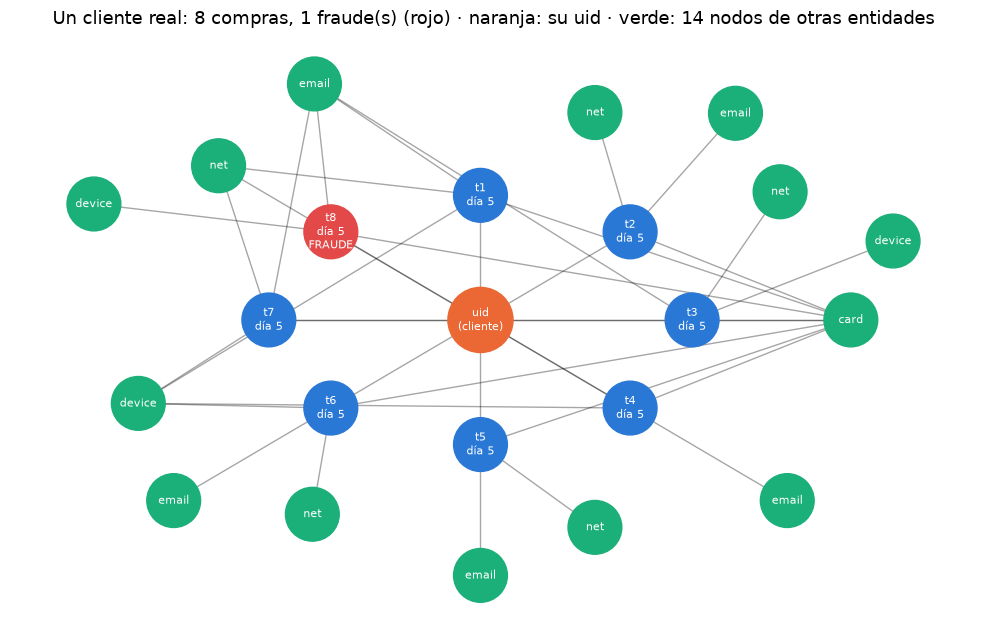

In [7]:
# ── Un cliente REAL dibujado: el grafo en miniatura ──────────────────────────
# Se busca el cliente más ilustrativo: 5-8 compras, tocando VARIAS entidades
# (email/device/net además de card) y, si existe, con fraude MEZCLADO con
# compras legítimas. El rótulo FRAUDE sale de isFraud y es solo para PINTAR:
# la red nunca recibe esa etiqueta como dato.
import networkx as nx

cl, ENTS = claves_txn["uid"], ["card", "email", "device", "net"]
tam = cl.value_counts()
mejor = None
for u in tam[(tam >= 5) & (tam <= 8)].index[:4000]:
    f = list(df.index[cl == u])
    tipos = sum(claves_txn[e][f].notna().any() for e in ENTS)
    fr = int(df.loc[f, "isFraud"].sum())
    puntos = tipos * 10 + (5 if 0 < fr < len(f) else (2 if fr else 0))
    if mejor is None or puntos > mejor[0]:
        mejor = (puntos, f, fr)
    if puntos >= 45: break                      # 4 entidades + fraude mixto
_, filas_u, n_fraude = mejor
filas_u = sorted(filas_u, key=lambda i: df.loc[i, "TransactionDT"])

G, colores, etiquetas = nx.Graph(), {}, {}
G.add_node("uid"); colores["uid"] = "#eb6834"; etiquetas["uid"] = "uid\n(cliente)"
for k, i in enumerate(filas_u, 1):
    G.add_node(f"t{k}"); G.add_edge(f"t{k}", "uid")
    fraude = bool(df.loc[i, "isFraud"])
    colores[f"t{k}"] = "#e34948" if fraude else "#2a78d6"
    dia = int(df.loc[i, "TransactionDT"] // 86400) + 1
    etiquetas[f"t{k}"] = f"t{k}\ndía {dia}" + ("\nFRAUDE" if fraude else "")

for ent in ENTS:
    for k, i in enumerate(filas_u, 1):
        v = claves_txn[ent][i]
        if pd.isna(v): continue
        nodo = f"{ent}:{str(v)[:12]}"
        if nodo not in G:
            G.add_node(nodo); colores[nodo] = "#1baf7a"; etiquetas[nodo] = ent
        G.add_edge(f"t{k}", nodo)

# ANILLOS: uid al centro · compras en el anillo interior (ordenadas por
# tiempo, t1 arriba y avanzando en sentido horario) · entidades en el anillo
# exterior, cada una en el ángulo promedio de las compras que la usan
pos = {"uid": (0.0, 0.0)}
n = len(filas_u)
for k in range(1, n + 1):
    a = np.pi / 2 - 2 * np.pi * (k - 1) / n          # t1 arriba, horario
    pos[f"t{k}"] = (np.cos(a), np.sin(a))
exteriores = [nodo for nodo in G if colores[nodo] == "#1baf7a"]
angulos = []
for nodo in exteriores:
    vec = [pos[v] for v in G[nodo]]
    a = np.arctan2(np.mean([p[1] for p in vec]), np.mean([p[0] for p in vec]))
    angulos.append((a, nodo))
angulos.sort()
minsep = 2 * np.pi / max(len(exteriores), 1)         # repartir sin encimarse
for j, (a, nodo) in enumerate(angulos):
    if j and a - angulos[j - 1][0] < minsep * 0.7:
        a = angulos[j - 1][0] + minsep * 0.7
        angulos[j] = (a, nodo)
    r = 1.75 if j % 2 == 0 else 2.05                 # dos radios alternos
    pos[nodo] = (np.cos(a) * r, np.sin(a) * r)
fig, ax = plt.subplots(figsize=(10, 6.5))
nx.draw_networkx_edges(G, pos, alpha=0.35, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=[colores[n] for n in G],
                       node_size=[2200 if n == "uid" else 1500 for n in G], ax=ax)
nx.draw_networkx_labels(G, pos, etiquetas, font_size=8, font_color="white", ax=ax)
n_ent = sum(1 for n in G if colores[n] == "#1baf7a")
ax.set_title(f"Un cliente real: {len(filas_u)} compras, {n_fraude} fraude(s) "
             f"(rojo) · naranja: su uid · verde: {n_ent} nodos de otras entidades")
ax.axis("off"); plt.tight_layout(); plt.show()


## [3] La GNN
Solo se toman los 10 vecinos mas recientes.
Para detener una red se usa ROC  porque es mas estable que PR por el desbalanceo.
Para elegir entre redes PR-AUC es la que indica de todos los detectados cuantos son fraudes.

En GraphSage se usa ["mean", "max", "std", "sum"]
GAT usa atención con promedio ponderado

In [8]:
import torch.nn.functional as F
from tqdm import tqdm
from torch import nn
from torch_geometric.nn import GATv2Conv, HeteroConv, SAGEConv
from torch_geometric.loader import NeighborLoader

TXN = "transaction"

class RedHetero(nn.Module):
    """GraphSAGE o GATv2 sobre el grafo heterogéneo. Una convolución por tipo
    de arista, sumadas en el destino. Los nodos de entidad ENTRAN EN CEROS
    (inductivo). Mínimo 2 capas: con una, la entidad llega vacía."""

    def __init__(self, arq, hp):
        super().__init__()
        self.arq, self.in_dim = arq, IN_DIM
        self.dropout, self.dim_embedding = hp["dropout"], hp["mlp_head_dim"]
        self.node_types, self.edge_types = data.metadata()
        conv = ((lambda h: SAGEConv((-1, -1), h, aggr=["mean", "max", "std", "sum"]))
                if arq == "graphsage" else
                (lambda h: GATv2Conv((-1, -1), h, heads=4, concat=False,
                                     add_self_loops=False)))
        self.convs = nn.ModuleList(
            HeteroConv({et: conv(hp["ancho"]) for et in self.edge_types}, aggr="sum")
            for _ in range(hp["capas"]))
        self.bns = nn.ModuleList(nn.BatchNorm1d(hp["ancho"])
                                 for _ in range(hp["capas"]))
        self.classifier = nn.Sequential(
            nn.Linear(hp["ancho"], hp["mlp_head_dim"]), nn.ReLU(),
            nn.Dropout(hp["dropout"]), nn.Linear(hp["mlp_head_dim"], 1))

    def _vecinos(self, conv, h_txn, x_txn):
        # el término que NO viene del propio nodo. SAGE = lin_l(agg) + lin_r(x):
        # se despeja restando los CINCO lin_r (uno por entidad — fallo E0).
        # GATv2 sin self-loops ya es pura suma de vecinos: no hay que restar.
        if self.arq != "graphsage":
            return h_txn
        resto = h_txn
        for et, sub in conv.convs.items():
            if et[2] == TXN:
                resto = resto - sub.lin_r(x_txn)
        return resto

    def encode(self, batch, solo_vecinos=False):
        # entidades en ceros; el vecindario se captura en la ÚLTIMA capa (en la
        # primera las entidades aún están vacías y no habría ni un vecino: E0)
        x = dict(batch.x_dict)
        for nt in self.node_types:
            if nt not in x or not x[nt].numel():
                x[nt] = torch.zeros(batch[nt].num_nodes, self.in_dim,
                                    device=batch[TXN].x.device)
        vecinos = None
        for i, (conv, bn) in enumerate(zip(self.convs, self.bns)):
            h = conv(x, batch.edge_index_dict)
            if solo_vecinos and i == len(self.convs) - 1:
                vecinos = self._vecinos(conv, h[TXN], x[TXN])
            nuevo = {nt: F.dropout(F.relu(bn(v) if nt == TXN else v),
                                   p=self.dropout, training=self.training)
                     for nt, v in h.items()}
            for nt, v in x.items():
                nuevo.setdefault(nt, v)
            x = nuevo
        return (x[TXN], vecinos) if solo_vecinos else x[TXN]

    def forward(self, batch):
        return self.classifier(self.encode(batch)).squeeze(-1)

def hacer_loader(capas, mask, shuffle, balancear=False, seed=42, batch_size=None):
    """Muestreo TEMPORAL: solo vecinas ANTERIORES, las 10 más recientes.
    Fanouts con tantos saltos como capas (viajan juntos, no se descuadran).
    Balanceo: fraudes reales repetidos hasta ~50% del lote."""
    try:                       # el muestreo temporal exige el sampler nativo
        import pyg_lib             # noqa: F401
    except ImportError:
        try:
            import torch_sparse    # noqa: F401
        except ImportError:
            raise SystemExit(
                "Falta el sampler nativo. Instálalo (también en Mac, hay "
                "ruedas oficiales desde pyg_lib 0.6):\n  pip install pyg_lib "
                "-f https://data.pyg.org/whl/torch-<TU_TORCH>+cpu.html")
    fan = {et: [CFG["vecinos_por_entidad"] if et[0] == TXN else 1] * capas
           for et in data.edge_types}
    semillas = mask
    if balancear:
        idx = torch.where(mask)[0]
        y = data[TXN].y[idx]
        fraude, normal = idx[y == 1], idx[y == 0]
        reps = np.random.default_rng(seed).choice(len(fraude), size=len(normal))
        semillas = torch.cat([normal, fraude[torch.tensor(reps)]])
    gen = torch.Generator(); gen.manual_seed(seed)
    return NeighborLoader(
        data, num_neighbors=fan, input_nodes=(TXN, semillas),
        batch_size=batch_size or CFG["batch_size"], shuffle=shuffle,
        generator=gen, time_attr="time", temporal_strategy="last",
        num_workers=CFG["num_workers"] if shuffle else 0,
        persistent_workers=shuffle)

@torch.no_grad()
def evaluar(modelo, loader):
    modelo.eval(); ys, ss = [], []
    for b in loader:
        b = b.to(DEVICE); n = b[TXN].batch_size
        ys.append(b[TXN].y[:n].cpu())
        ss.append(torch.sigmoid(modelo(b)[:n]).cpu())
    return torch.cat(ys).numpy(), torch.cat(ss).numpy()

def entrenar_gnn(arq, seed, hp, epochs=None, patience=None, verbose=True):
    """Early stopping por ROC en gnn_valida; devuelve los pesos del PICO."""
    epochs, patience = epochs or CFG["epochs"], patience or CFG["patience"]
    set_seed(seed)
    modelo = RedHetero(arq, hp).to(DEVICE)
    opt = torch.optim.Adam(modelo.parameters(), lr=hp["lr"],
                           weight_decay=hp["weight_decay"])
    crit = torch.nn.BCEWithLogitsLoss()     # pos_weight 1: el balanceo ya iguala
    tr = hacer_loader(hp["capas"], torch.from_numpy(VENT["gnn_entrena"]),
                      shuffle=True, balancear=True, seed=seed)
    va = hacer_loader(hp["capas"], torch.from_numpy(VENT["gnn_valida"]), shuffle=False)
    curva, mejor, malas = [], {"auc": 0, "pr": 0, "epoca": 0, "state": None}, 0
    barra = tqdm(range(1, epochs + 1), desc=f"{arq} s{seed}", unit="época",
                 disable=not verbose, ncols=100)
    for ep in barra:
        modelo.train()
        for b in tr:
            b = b.to(DEVICE); opt.zero_grad()
            n = b[TXN].batch_size
            loss = crit(modelo(b)[:n], b[TXN].y[:n])
            loss.backward(); opt.step()
        y_v, s_v = evaluar(modelo, va)
        roc, pr = roc_auc_score(y_v, s_v), average_precision_score(y_v, s_v)
        curva.append({"epoca": ep, "roc": roc, "pr_auc": pr})
        if roc > mejor["auc"]:
            mejor, malas = {"auc": roc, "pr": pr, "epoca": ep,
                            "state": copy.deepcopy(modelo.state_dict())}, 0
        else:
            malas += 1
        barra.set_postfix(roc=f"{roc:.4f}", pr=f"{pr:.4f}",
                          mejor=f"e{mejor['epoca']}:{mejor['auc']:.4f}",
                          paciencia=f"{malas}/{patience}")
        if malas >= patience:
            barra.close()
            break
    modelo.load_state_dict(mejor["state"])
    return modelo, mejor, pd.DataFrame(curva)


In [9]:
# Búsqueda de hiperparámetros — YA CORRIÓ
# 30 trial con 12 epocas, los primero 5 trial no se tocan, a partir del 6 en la segunda epoca si el PR es mejor que el mejor se detine el trial, si un
# Maximo 12 minutos por trial para evitar arquitecturas lentas, si un trial va ganandole al mejor se le da mas tiempo
EJECUTAR_OPTUNA = False
if EJECUTAR_OPTUNA:
    import optuna
    def _trial(t):
        hp = {"lr": t.suggest_float("lr", 1e-4, 1e-2, log=True),
              "dropout": t.suggest_float("dropout", 0.0, 0.5),
              "ancho": t.suggest_categorical("ancho", [64, 128, 256]),
              "capas": t.suggest_int("capas", 2, 3),
              "weight_decay": t.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
              "mlp_head_dim": FORZAR_MLP_HEAD_DIM
                              or t.suggest_categorical("mlp_head_dim", [16, 32, 64])}
        return entrenar_gnn(ARQUITECTURA, 42, hp, epochs=12, verbose=False)[1]["pr"]
    estudio = optuna.create_study(direction="maximize")
    estudio.optimize(_trial, n_trials=30, show_progress_bar=True)
    HP = {**HP, **estudio.best_params}
    if FORZAR_MLP_HEAD_DIM: HP["mlp_head_dim"] = FORZAR_MLP_HEAD_DIM
print("hiperparámetros en uso →", HP)


hiperparámetros en uso → {'lr': 0.0003620595965204201, 'dropout': 0.3376681522595246, 'ancho': 256, 'capas': 3, 'weight_decay': 8.376070586201612e-06, 'mlp_head_dim': 16}


In [10]:
# Las 6 redes (2 arquitecturas x 3 semillas) — YA CORRIÓ: ganó graphsage seed 2026
# Se valida por PR
ENTRENAR_6_REDES = False
if ENTRENAR_6_REDES:
    from tqdm import tqdm
    combos = [(a, s) for a in ["graphsage", "gatv2"] for s in [42, 123, 2026]]
    marcas = {c: entrenar_gnn(*c, HP, verbose=False)[1]["pr"]
              for c in tqdm(combos, desc="6 redes", unit="red")}
    print({f"{a} s{s}": round(v, 4) for (a, s), v in marcas.items()})
    ARQUITECTURA, SEED = max(marcas, key=marcas.get)
print(f"red elegida: {ARQUITECTURA} seed {SEED}")


red elegida: graphsage seed 2026


In [11]:
# ── LA RED: entrenarla AQUÍ o cargar una ya entrenada
# La red entra las transacciones 93 feature, las entidades campos en el vector en cero y las conexiones (indices que indican qlas conexiones)
# Antes 256->256->256->64->1 red 256->256->256->16->1
# Grasage se saca emb_v y emb, emb se obtine el vector de 256 y a la entrada de la transaccion que se analiza se multiplica por los pesos
# de la red y se resta de la salida para obtener a emb

# Grasage: Funcion activación RELU (softmax GAT en la primera campa junto a RELU para balancear los resultados), Funcion pedida BCE (entropía cruzada binaria), Resultado SIGMOID y ajustar pesos ADAM

# Gat al final entrega solo el embeding de los vecinos
ENTRENAR_AQUI = True
RUTA_CHECKPOINT = "../models/graphsage_seed2026.pt"

t0 = time.time()
if ENTRENAR_AQUI:
    model, mejor, curva = entrenar_gnn(ARQUITECTURA, SEED, HP)
else:
    ck = torch.load(RUTA_CHECKPOINT, map_location="cpu", weights_only=False)
    assert ck["in_dim"] == IN_DIM, (
        f"el checkpoint espera {ck['in_dim']} features y el cuaderno produjo "
        f"{IN_DIM}: los datos no se procesaron igual que en esa corrida")
    HP = {**HP, "ancho": ck["hidden_dims"][0], "capas": len(ck["hidden_dims"]),
          "mlp_head_dim": ck["mlp_head_dim"]}       # manda el checkpoint
    model = RedHetero(ck["model_name"], HP).to(DEVICE)
    model.load_state_dict(ck["state_dict"])         # los pesos del PICO
    # verificación: puntuar gnn_valida (1-3 min) — debe dar el ROC conocido
    y_v, s_v = evaluar(model, hacer_loader(HP["capas"],
        torch.from_numpy(VENT["gnn_valida"]), shuffle=False))
    mejor = {"auc": roc_auc_score(y_v, s_v),
             "pr": average_precision_score(y_v, s_v),
             "epoca": ck.get("best_epoch", 0)}
    curva = pd.DataFrame([{"epoca": mejor["epoca"], "roc": mejor["auc"],
                           "pr_auc": mejor["pr"]}])
    print(f"cargada: {ck['model_name']} seed {ck['seed']} | {ck['hidden_dims']} "
          f"| embedding {ck['mlp_head_dim']}d | pico en época {ck.get('best_epoch')}")

print(f"val ROC {mejor['auc']:.4f} · PR-AUC {mejor['pr']:.4f} | "
      f"{(time.time()-t0)/60:.1f} min")


graphsage s2026:  20%|▏| 10/50 [24:46<1:39:04, 148.61s/época, mejor=e1:0.7989, paciencia=10/10, pr=0

val ROC 0.7989 · PR-AUC 0.1903 | 24.8 min


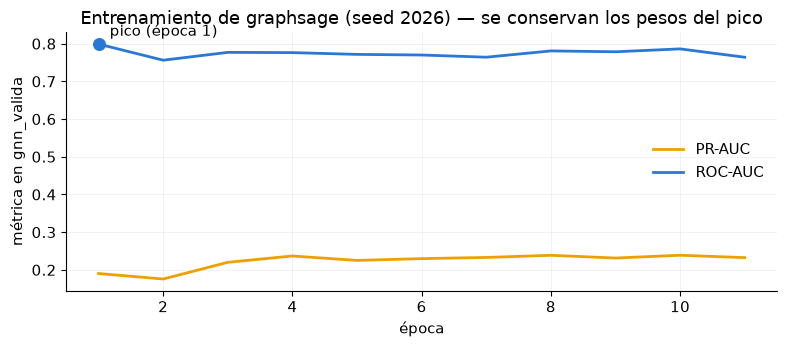

In [12]:
# ── Gráfico: curva de entrenamiento ──────────────────────────────────────────
# Solo existe si la red se ENTRENÓ en el cuaderno: un checkpoint cargado trae
# los pesos del pico, no la historia de épocas.
if len(curva) <= 1:
    print("Red cargada de checkpoint: no hay curva de entrenamiento que "
          "dibujar (el .pt solo guarda los pesos del pico). Su calidad ya "
          f"quedó verificada arriba: ROC {mejor['auc']:.4f} en gnn_valida. "
          "Para ver la curva, entrena con la celda [3].")
else:
    fig, ax = plt.subplots(figsize=(8, 3.6))
    ax.plot(curva["epoca"], curva["pr_auc"], color=COLOR["gnn_sola"], lw=2,
            label="PR-AUC")
    ax.plot(curva["epoca"], curva["roc"], color=COLOR["control"], lw=2,
            label="ROC-AUC")
    ax.scatter([mejor["epoca"]], [mejor["auc"]], s=70, color=COLOR["control"],
               zorder=3)
    ax.annotate(f"pico (época {mejor['epoca']})", (mejor["epoca"], mejor["auc"]),
                textcoords="offset points", xytext=(8, 6))
    ax.set(xlabel="época", ylabel="métrica en gnn_valida",
           title=f"Entrenamiento de {ARQUITECTURA} (seed {SEED}) — "
                 "se conservan los pesos del pico")
    ax.legend(frameon=False)
    plt.tight_layout(); plt.show()


## [4] El embedding
Tranforma la salida de la red en tablas pas xgboost
- `emb` — «TX + vecindario» → lo consumirá `solo_gnn`
- `embv` — «vecindario» → lo consumirá `gnn_mas_tabular` (sus
  features propias ya van en el bloque tabular)
- `gnn_score` — la probabilidad del camino GNN completo (`gnn_sola`)


In [13]:
@torch.no_grad()
def describir(modelo, idx, capas):
    """emb (yo+vecindario), embv (solo vecindario) y score, en UNA pasada."""
    modelo.eval()
    mask = torch.zeros(n_txn, dtype=torch.bool); mask[torch.as_tensor(idx)] = True
    loader = hacer_loader(capas, mask, shuffle=False, batch_size=2048)
    proy = nn.Sequential(modelo.classifier[0], modelo.classifier[1])
    d = modelo.dim_embedding
    E, V = np.zeros((n_txn, d), np.float32), np.zeros((n_txn, d), np.float32)
    S = np.zeros(n_txn, np.float32)
    for b in loader:
        b = b.to(DEVICE); n = b[TXN].batch_size
        h, vec = modelo.encode(b, solo_vecinos=True)
        s = torch.sigmoid(modelo.classifier(h[:n])).squeeze(-1)
        fil = b[TXN].n_id[:n].cpu().numpy()
        E[fil], V[fil], S[fil] = (proy(h[:n]).cpu().numpy(),
                                  proy(vec[:n]).cpu().numpy(), s.cpu().numpy())
    return E[idx], V[idx], S[idx]

t0 = time.time()
node_idx = np.where(~VENT["gnn_entrena"])[0]   # la red memorizó gnn_entrena
emb, embv, gnn_score = describir(model, node_idx, HP["capas"])
print(f"{len(node_idx):,} filas descritas · {emb.shape[1]} dimensiones · "
      f"{(time.time()-t0)/60:.1f} min")

def _cols(pref, M):
    B = np.full((n_txn, M.shape[1]), np.nan, dtype=np.float32); B[node_idx] = M
    return pd.DataFrame(B, columns=[f"{pref}{i}" for i in range(M.shape[1])])
df = pd.concat([df, _cols("emb_", emb), _cols("embv_", embv)], axis=1)
df["gnn_score"] = np.nan; df.loc[node_idx, "gnn_score"] = gnn_score
COLS_EMB  = [c for c in df.columns if c.startswith("emb_")]
COLS_EMBV = [c for c in df.columns if c.startswith("embv_")]


164,747 filas descritas · 16 dimensiones · 1.3 min


## [5] Las tres cabezas XGBoost

- Base tabular = features tras la ablación.
- SMOTE solo sobre las filas de entrenamiento (fraude sintético hasta 1:2).
- Nº de árboles por early stopping.

- Resultado: sigmoid.
- Función perdida: BCE.
- Optune 30 trial completo.
- En el entrenamiento elije la cantidad de arboles por el PR, ejecuta 1000 rondas, si llega a 50 rondas sin mejoras para y elije la mejor. Siempre al final de cada ronda se le pasa la informacion a la siguiente en funcion del error.



control            93 col |  717 árboles | PR-AUC validan 0.4009
solo_gnn           16 col |   88 árboles | PR-AUC validan 0.2333
gnn_mas_tabular   109 col |  881 árboles | PR-AUC validan 0.4023


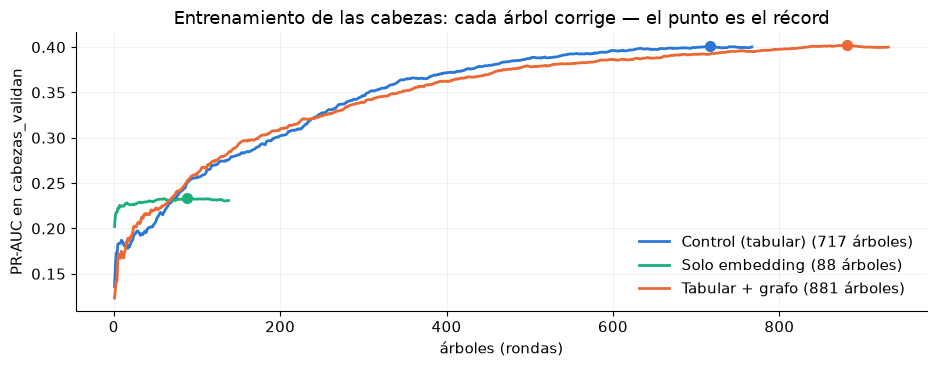

In [14]:
import xgboost as xgb
from imblearn.over_sampling import SMOTE

# La búsqueda de XGBoost (30 trials sobre `control`; las 3 cabezas HEREDAN
# — buscar por cabeza sobreajusta la validación, medido) ya corrió en el
# pipeline. Su resultado queda hardcodeado aquí:
PARAMS_XGB = {
    "objective": "binary:logistic", "eval_metric": "aucpr",
    "tree_method": "hist", "device": "cuda" if DEVICE.type == "cuda" else "cpu",
    "max_depth": 6, "learning_rate": 0.05, "subsample": 0.8,
    "colsample_bytree": 0.8, "min_child_weight": 5, "seed": 42}
#objective": "binary:logistic -> clasificación binaria
#eval_metric -> metrica evlauación
#tree_method -> prueba trozos completos de arboles
#max_depth -> maximo de preguntas por arbol
#subsample -> porcentaje de intercanbio de los datos entre ronda
#colsample_bytree -> busca filas donde las columnas sean variadas mas aleatorias
#min_child_weight -> no menos de 5 capas por arbol

cols_base = [c for c in feature_cols
             if not any(c.startswith(p) and len(c) > len(p) and c[len(p)].isdigit()
                        for p in CFG["ablacion"])] + sorted(grados)
VARIANTES = {"control": cols_base, "solo_gnn": COLS_EMB,
             "gnn_mas_tabular": cols_base + COLS_EMBV}

m_ent, m_val, m_exa = (VENT["cabezas_entrenan"], VENT["cabezas_validan"],
                       VENT["examen"])
y_ent, y_val, y_exa = (df.loc[m, "isFraud"].values.astype(int)
                       for m in (m_ent, m_val, m_exa))

cabezas, scores_exa, historiales = {}, {}, {}
for nombre, cols in VARIANTES.items():
    # SMOTE por cabeza: los vecinos más cercanos cambian con las columnas
    Xs, ys = SMOTE(sampling_strategy=CFG["smote"]["sampling_strategy"],
                   k_neighbors=CFG["smote"]["k_neighbors"], random_state=42
                   ).fit_resample(df.loc[m_ent, cols].values.astype(np.float32),
                                  y_ent)
    notas = {}                       # la nota (PR-AUC en validan) tras CADA árbol
    booster = xgb.train(
        PARAMS_XGB, xgb.DMatrix(Xs, label=ys), num_boost_round=1000,
        evals=[(xgb.DMatrix(df.loc[m_val, cols].values.astype(np.float32),
                            label=y_val), "validan")],
        early_stopping_rounds=CFG["early_stopping_xgb"], verbose_eval=False,
        evals_result=notas)
    historiales[nombre] = notas["validan"]["aucpr"]
    cabezas[nombre] = booster
    scores_exa[nombre] = booster.predict(
        xgb.DMatrix(df.loc[m_exa, cols].values.astype(np.float32)),
        iteration_range=(0, booster.best_iteration + 1))
    print(f"{nombre:<16} {len(cols):>4} col | {booster.best_iteration + 1:>4} "
          f"árboles | PR-AUC validan {booster.best_score:.4f}")

scores_exa["gnn_sola"] = df.loc[m_exa, "gnn_score"].fillna(0).values


# ── Gráfico:
fig, ax = plt.subplots(figsize=(9.5, 3.8))
for nombre, hist in historiales.items():
    ax.plot(range(1, len(hist) + 1), hist, color=COLOR[nombre], lw=2,
            label=f"{NOMBRE[nombre]} ({cabezas[nombre].best_iteration + 1} árboles)")
    b = cabezas[nombre].best_iteration
    ax.scatter([b + 1], [hist[b]], s=50, color=COLOR[nombre], zorder=3)
ax.set(xlabel="árboles (rondas)", ylabel="PR-AUC en cabezas_validan",
       title="Entrenamiento de las cabezas: cada árbol corrige — el punto es el récord")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## [6] El veredicto


In [15]:
# precisión = de lo que ALERTÉ (score >= 0.5), ¿qué fracción era fraude real?
# Ojo con gnn_sola: entrena con lotes balanceados y sus scores corren altos,
# así que su precisión a 0.5 se lee con cautela (alerta de más).
def precision_05(y, sc):
    alerta = sc >= 0.5
    return (alerta & (y == 1)).sum() / max(alerta.sum(), 1)

filas = []
for s, sc in scores_exa.items():
    filas.append({"sistema": s,
                  "PR-AUC": average_precision_score(y_exa, sc),
                  "ROC-AUC": roc_auc_score(y_exa, sc),
                  "precisión": precision_05(y_exa, sc)})
RES = pd.DataFrame(filas).set_index("sistema").round(4)
display(RES)

# bootstrap EMPAREJADO: la misma remuestra de filas para ambos sistemas
rng = np.random.default_rng(42)
a, b = scores_exa["gnn_mas_tabular"], scores_exa["control"]
deltas = []
for _ in range(1000):
    i = rng.integers(0, len(y_exa), len(y_exa))
    if y_exa[i].sum():
        deltas.append(average_precision_score(y_exa[i], a[i])
                      - average_precision_score(y_exa[i], b[i]))
lo, hi = np.percentile(deltas, [2.5, 97.5])
delta = RES.loc["gnn_mas_tabular", "PR-AUC"] - RES.loc["control", "PR-AUC"]


,PR-AUC,ROC-AUC,precisión
sistema,,,
control,0.3483,0.8277,0.6890
solo_gnn,0.2281,0.7695,0.1637
gnn_mas_tabular,0.3289,0.8197,0.6364
gnn_sola,0.2358,0.7433,0.1210


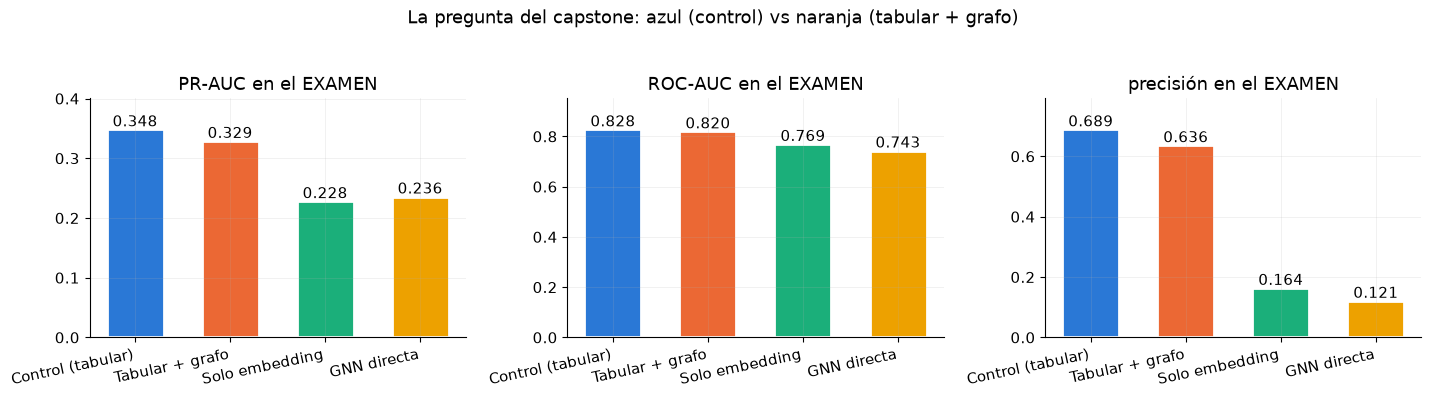

In [16]:
# ── Gráfico: la comparación final ────────────────────────────────────────────
orden = ["control", "gnn_mas_tabular", "solo_gnn", "gnn_sola"]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))
for ax, met in zip(axes, ["PR-AUC", "ROC-AUC", "precisión"]):
    vals = [RES.loc[s, met] for s in orden]
    ax.bar(range(4), vals, width=0.6, color=[COLOR[s] for s in orden],
           edgecolor="white", linewidth=2)
    for xi, v in enumerate(vals):
        ax.text(xi, v + max(vals) * 0.015, f"{v:.3f}", ha="center")
    ax.set_xticks(range(4), [NOMBRE[s] for s in orden], rotation=12, ha="right")
    ax.set(title=f"{met} en el EXAMEN", ylim=(0, max(vals) * 1.15))
fig.suptitle("La pregunta del capstone: azul (control) vs naranja (tabular + grafo)", y=1.04)
plt.tight_layout(); plt.show()


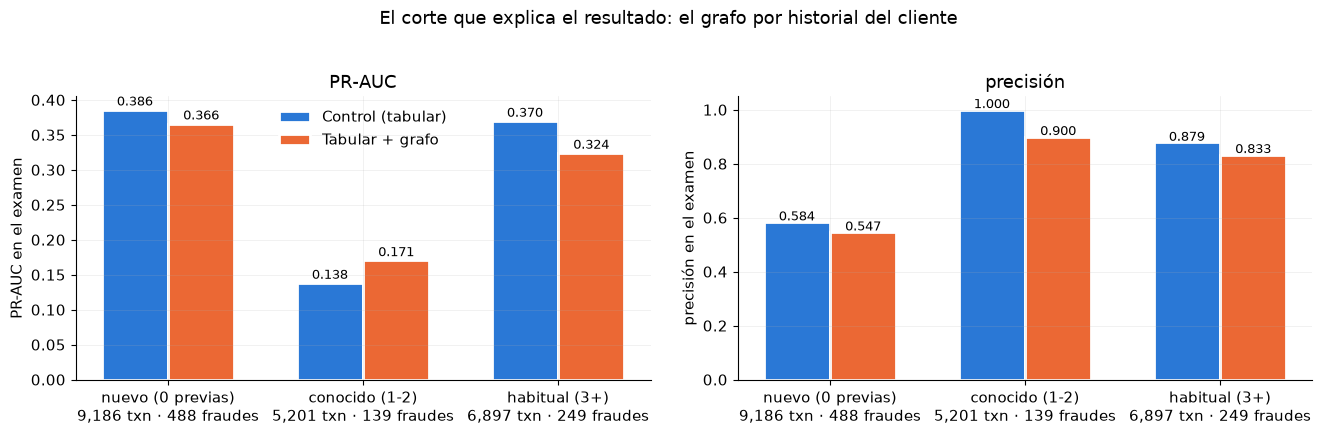

In [17]:
# ── Gráfico: ¿dónde ayuda y dónde estorba el grafo? (historial del uid) ──────
# previas_uid es CAUSAL: compras ANTERIORES del uid de cada fila
pu = previas_uid[np.where(m_exa)[0]]
grupos = [("nuevo (0 previas)", pu == 0), ("conocido (1-2)", (pu >= 1) & (pu <= 2)),
          ("habitual (3+)", pu >= 3)]
sistemas = ["control", "gnn_mas_tabular"]
etiquetas = [f"{et}\n{int(g.sum()):,} txn · {int(y_exa[g].sum())} fraudes"
             for et, g in grupos]
x, w = np.arange(3), 0.34

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
for ax, met in zip(axes, ["PR-AUC", "precisión"]):
    for k, s in enumerate(sistemas):
        if met == "PR-AUC":
            vals = [average_precision_score(y_exa[g], scores_exa[s][g])
                    for _, g in grupos]
        else:
            vals = [precision_05(y_exa[g], scores_exa[s][g]) for _, g in grupos]
        ax.bar(x + (k - 0.5) * w, vals, w, color=COLOR[s], label=NOMBRE[s],
               edgecolor="white", linewidth=2)
        for xi, v in zip(x + (k - 0.5) * w, vals):
            ax.text(xi, v + 0.006, f"{v:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x, etiquetas)
    ax.set(ylabel=f"{met} en el examen", title=met)
axes[0].legend(frameon=False)
fig.suptitle("El corte que explica el resultado: el grafo por historial del cliente",
             y=1.03)
plt.tight_layout(); plt.show()